In [1]:
import pandas as pd
import numpy as np

master_df = pd.read_csv(
    "../data/processed/master_stock_data.csv"
)

master_df.head()

,Date,Close,High,Low,Open,Volume,Company
0,2019-01-01,496.196381,498.985034,491.371654,498.077624,9746670,Reliance
1,2019-01-02,489.733887,498.852220,487.343625,493.319235,15628818,Reliance
2,2019-01-03,483.691925,493.363540,482.518940,490.220816,16288287,Reliance
3,2019-01-04,486.303436,488.870748,478.535167,485.750155,18516544,Reliance
4,2019-01-07,489.003540,495.067675,487.343638,489.999475,12060290,Reliance


# Section 1: Calculate Daily Returns

In [2]:
master_df['Daily_Return'] = (
    master_df.groupby('Company')['Close']
    .pct_change()
)
master_df['Daily_Return']

0             NaN
1       -0.013024
2       -0.012337
3        0.005399
4        0.005552
           ...   
10369   -0.002463
10370   -0.003035
10371   -0.002735
10372   -0.001294
10373    0.008704
Name: Daily_Return, Length: 10374, dtype: float64

# Section 2: Annualized Return

In [3]:
annual_return = (
    master_df.groupby('Company')['Daily_Return']
    .mean()
    * 252
)

# Section 3: Annualized Volatility

In [4]:
annual_volatility = (
    master_df.groupby('Company')['Daily_Return']
    .std()
    * (252 ** 0.5)
)

Why 252?
≈ 252 trading days in a year 
Example-0.001 daily return
× 252
=25.2% annual return

# Section 4: Sharpe Ratio

In [5]:
risk_free_rate = 0.065
sharpe_ratio = (
    annual_return - risk_free_rate
) / annual_volatility

Use RBI repo rate:

risk_free_rate = 0.065

Sharpe < 1      Poor
Sharpe 1–2      Good
Sharpe > 2      Excellent

# Section 5: Maximum Drawdown

In [6]:
drawdown_results = {}

for company in master_df['Company'].unique():

    temp = master_df[
        master_df['Company'] == company
    ].copy()

    temp['Cumulative_Return'] = (
        1 + temp['Daily_Return']
    ).cumprod()

    temp['Running_Max'] = (
        temp['Cumulative_Return']
        .cummax()
    )

    temp['Drawdown'] = (
        temp['Cumulative_Return']
        - temp['Running_Max']
    ) / temp['Running_Max']

    drawdown_results[company] = (
        temp['Drawdown'].min()
    )

max_drawdown = pd.Series(drawdown_results)

max_drawdown

Reliance    -0.450884
Infosys     -0.365498
HDFC_Bank   -0.410550
ITC         -0.511127
Maruti      -0.480463
SBI         -0.594925
dtype: float64

Imagine:

Day 1 → ₹100
Day 2 → ₹120 ← Highest point
Day 3 → ₹110
Day 4 → ₹90

Investor bought at ₹120.

Price fell to ₹90.

Loss:

(90 - 120) / 120

= -25%

Maximum Drawdown tells:

"What was the biggest fall from a peak?"

In [7]:
risk_df = pd.DataFrame({
    'Annual_Return': annual_return,
    'Annualized_Volatility': annual_volatility,
    'Sharpe_Ratio': sharpe_ratio,
    'Max_Drawdown': max_drawdown
})

risk_df

,Annual_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown
HDFC_Bank,0.129592,0.249229,0.259168,-0.410550
ITC,0.125690,0.239270,0.253646,-0.511127
Infosys,0.194723,0.274706,0.472224,-0.365498
Maruti,0.168192,0.289660,0.356251,-0.480463
Reliance,0.203808,0.280953,0.494062,-0.450884
SBI,0.233600,0.315618,0.534189,-0.594925


# Step 6: Load NIFTY

In [8]:
nifty = pd.read_csv("../data/raw/NIFTY50.csv")

print(nifty.columns)

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [9]:
nifty = pd.read_csv(
    "../data/raw/NIFTY50.csv",
    skiprows=2
)

nifty.head()

,Date,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,2019-01-02,10792.500000,10895.349609,10735.049805,10868.849609,309700
1,2019-01-03,10672.250000,10814.049805,10661.250000,10796.799805,286200
2,2019-01-04,10727.349609,10741.049805,10628.650391,10699.700195,296600
3,2019-01-07,10771.799805,10835.950195,10750.150391,10804.849609,269400
4,2019-01-08,10802.150391,10818.450195,10733.250000,10786.250000,277700


In [10]:
print(nifty.columns)

Index(['Date', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5'],
      dtype='object')


In [11]:
nifty.columns = [
    'Date',
    'Close',
    'High',
    'Low',
    'Open',
    'Volume'
]

nifty.head()

,Date,Close,High,Low,Open,Volume
0,2019-01-02,10792.500000,10895.349609,10735.049805,10868.849609,309700
1,2019-01-03,10672.250000,10814.049805,10661.250000,10796.799805,286200
2,2019-01-04,10727.349609,10741.049805,10628.650391,10699.700195,296600
3,2019-01-07,10771.799805,10835.950195,10750.150391,10804.849609,269400
4,2019-01-08,10802.150391,10818.450195,10733.250000,10786.250000,277700


In [12]:
nifty['Date'] = pd.to_datetime(nifty['Date'])

# Step 7: create NIFTY returns

In [13]:
nifty['Nifty_Return'] = (
    nifty['Close']
    .pct_change()
)

nifty[['Date','Close','Nifty_Return']].head()

,Date,Close,Nifty_Return
0,2019-01-02,10792.500000,NaN
1,2019-01-03,10672.250000,-0.011142
2,2019-01-04,10727.349609,0.005163
3,2019-01-07,10771.799805,0.004144
4,2019-01-08,10802.150391,0.002818


In [14]:
print(nifty.dtypes)

Date            datetime64[ns]
Close                  float64
High                   float64
Low                    float64
Open                   float64
Volume                   int64
Nifty_Return           float64
dtype: object


# Step 8: Calculate Beta

In [15]:
print(master_df['Date'].dtype)
print(nifty['Date'].dtype)

object
datetime64[ns]


In [16]:
master_df['Date'] = pd.to_datetime(master_df['Date'])

In [17]:
print(master_df['Date'].dtype)
print(nifty['Date'].dtype)

datetime64[ns]
datetime64[ns]


In [18]:
from sklearn.linear_model import LinearRegression

beta_dict = {}

for company in master_df['Company'].unique():

    stock = master_df[
        master_df['Company'] == company
    ][['Date', 'Daily_Return']]

    merged = pd.merge(
        stock,
        nifty[['Date', 'Nifty_Return']],
        on='Date',
        how='inner'
    )

    merged = merged.dropna()

    X = merged[['Nifty_Return']]
    y = merged['Daily_Return']

    model = LinearRegression()
    model.fit(X, y)

    beta_dict[company] = model.coef_[0]

beta = pd.Series(beta_dict)

beta

Reliance     1.102506
Infosys      0.864032
HDFC_Bank    1.068075
ITC          0.675346
Maruti       1.004880
SBI          1.253067
dtype: float64

| Beta  | Meaning                   |
| ----- | ------------------------- |
| β = 1 | Same as market            |
| β > 1 | More volatile than market |
| β < 1 | Less volatile than market |
| β < 0 | Moves opposite market     |


In [19]:
risk_df['Beta'] = beta

risk_df

,Annual_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown,Beta
HDFC_Bank,0.129592,0.249229,0.259168,-0.410550,1.068075
ITC,0.125690,0.239270,0.253646,-0.511127,0.675346
Infosys,0.194723,0.274706,0.472224,-0.365498,0.864032
Maruti,0.168192,0.289660,0.356251,-0.480463,1.004880
Reliance,0.203808,0.280953,0.494062,-0.450884,1.102506
SBI,0.233600,0.315618,0.534189,-0.594925,1.253067


# Step 9: Create Stock Risk Index (SRI)

Normalize Volatility

In [21]:
risk_df['Volatility_Score'] = (
    (
        risk_df['Annualized_Volatility']
        - risk_df['Annualized_Volatility'].min()
    )
    /
    (
        risk_df['Annualized_Volatility'].max()
        - risk_df['Annualized_Volatility'].min()
    )
) * 10

Normalize Drawdown

In [22]:
risk_df['Drawdown_Score'] = (
    (
        risk_df['Max_Drawdown'].abs()
        - risk_df['Max_Drawdown'].abs().min()
    )
    /
    (
        risk_df['Max_Drawdown'].abs().max()
        - risk_df['Max_Drawdown'].abs().min()
    )
) * 10

Create SRI

In [23]:
risk_df['SRI'] = (
    0.6 * risk_df['Volatility_Score']
    +
    0.4 * risk_df['Drawdown_Score']
)

What are we trying to do?

Suppose you have 6 students:

Reliance
SBI
Infosys
ITC
Maruti
HDFC Bank

You want to know:

"Who is the riskiest student in the class?"

But risk comes from 2 things:

1. Volatility

How much does the stock jump up and down?

Example:

Student A:
90 → 91 → 89 → 90

Very stable
Student B:
90 → 120 → 70 → 140

Very crazy

Student B is riskier.

2. Drawdown

How badly can the stock crash?

Example:

100 → 120 → 110

Worst fall:

120 → 110
=
-8%

Another stock:

100 → 150 → 60

Worst fall:

150 → 60
=
-60%

Much riskier.

Problem

Volatility and Drawdown have different scales.

Example:

Company	Volatility
ITC	0.20
SBI	0.40
Company	Drawdown
ITC	-0.30
SBI	-0.60

We cannot add them directly.

It's like:

Height = centimeters
Weight = kilograms

Different units.

So first we convert everything to the same scale.

Step 1: Normalize Volatility

Your code:

risk_df['Volatility_Score'] = (
    (
        risk_df['Annualized_Volatility']
        -
        risk_df['Annualized_Volatility'].min()
    )
    /
    (
        risk_df['Annualized_Volatility'].max()
        -
        risk_df['Annualized_Volatility'].min()
    )
) * 10

Suppose:

Company	Volatility
ITC	0.20
Infosys	0.30
SBI	0.40

Minimum:

0.20

Maximum:

0.40

For ITC:

(0.20 - 0.20)
/
(0.40 - 0.20)

=
0

Score:

0 × 10
=
0

For SBI:

(0.40 - 0.20)
/
(0.40 - 0.20)

=
1

Score:

1 × 10
=
10

For Infosys:

(0.30 - 0.20)
/
(0.40 - 0.20)

=
0.5

Score:

0.5 × 10
=
5

Now:

Company	Volatility Score
ITC	0
Infosys	5
SBI	10

Everyone is on a 0–10 scale.

Step 2: Normalize Drawdown

Your code:

risk_df['Drawdown_Score']

Suppose:

Company	Drawdown
ITC	-0.30
Infosys	-0.45
SBI	-0.60

We use:

.abs()

because:

-0.60

means

60% crash

Risk cares about size, not the minus sign.

Becomes:

Company	Drawdown
ITC	0.30
Infosys	0.45
SBI	0.60

Normalize exactly the same way.

Result:

Company	Drawdown Score
ITC	0
Infosys	5
SBI	10
Step 3: Create SRI

Your code:

risk_df['SRI'] = (
    0.6 * risk_df['Volatility_Score']
    +
    0.4 * risk_df['Drawdown_Score']
)

Think of a school report card.

Math = 60%
Science = 40%

Final score:

0.6 × Math
+
0.4 × Science

Same idea.

Example:

Reliance:

Volatility Score = 8
Drawdown Score = 6

SRI:

Final:

SRI = 7.2

Another stock:

Volatility Score = 2
Drawdown Score = 1

SRI:

Much safer.

Why 60% and 40%?

You decided:

Volatility
=
more important

So:

60%
Drawdown
=
slightly less important

So:

40%

This is your custom risk model.

What does SRI mean?
0
=
Very Safe
10
=
Very Risky

Example:

Company	SRI
ITC	1.2
HDFC	3.5
Infosys	5.1
Reliance	7.4
SBI	9.3

Interpretation:

ITC
=
Safe
SBI
=
Dangerous but potentially higher return

# Step 10: Risk Classification

In [24]:
def classify_risk(score):

    if score <= 3:
        return "Low Risk"

    elif score <= 7:
        return "Medium Risk"

    else:
        return "High Risk"

In [25]:
risk_df['Risk_Level'] = (
    risk_df['SRI']
    .apply(classify_risk)
)

In [26]:
risk_df[
    [
        'SRI',
        'Risk_Level'
    ]
]

,SRI,Risk_Level
HDFC_Bank,1.568128,Low Risk
ITC,2.539010,Low Risk
Infosys,2.784818,Low Risk
Maruti,5.964430,Medium Risk
Reliance,4.764431,Medium Risk
SBI,10.000000,High Risk


In [27]:
risk_df = risk_df.sort_values(
    by='SRI',
    ascending=False
)

risk_df

,Annual_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown,Beta,Volatility_Score,Drawdown_Score,SRI,Risk_Level
SBI,0.233600,0.315618,0.534189,-0.594925,1.253067,10.000000,10.000000,10.000000,High Risk
Maruti,0.168192,0.289660,0.356251,-0.480463,1.004880,6.600070,5.010969,5.964430,Medium Risk
Reliance,0.203808,0.280953,0.494062,-0.450884,1.102506,5.459594,3.721687,4.764431,Medium Risk
Infosys,0.194723,0.274706,0.472224,-0.365498,0.864032,4.641363,0.000000,2.784818,Low Risk
ITC,0.125690,0.239270,0.253646,-0.511127,0.675346,0.000000,6.347524,2.539010,Low Risk
HDFC_Bank,0.129592,0.249229,0.259168,-0.410550,1.068075,1.304441,1.963659,1.568128,Low Risk


In [28]:
risk_df.to_csv(
    "../data/processed/risk_summary.csv"
)

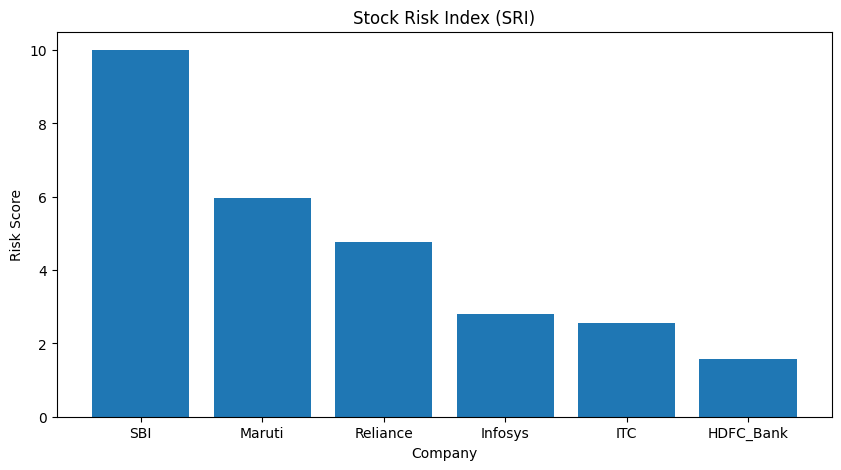

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    risk_df.index,
    risk_df['SRI']
)

plt.title("Stock Risk Index (SRI)")
plt.xlabel("Company")
plt.ylabel("Risk Score")

plt.show()

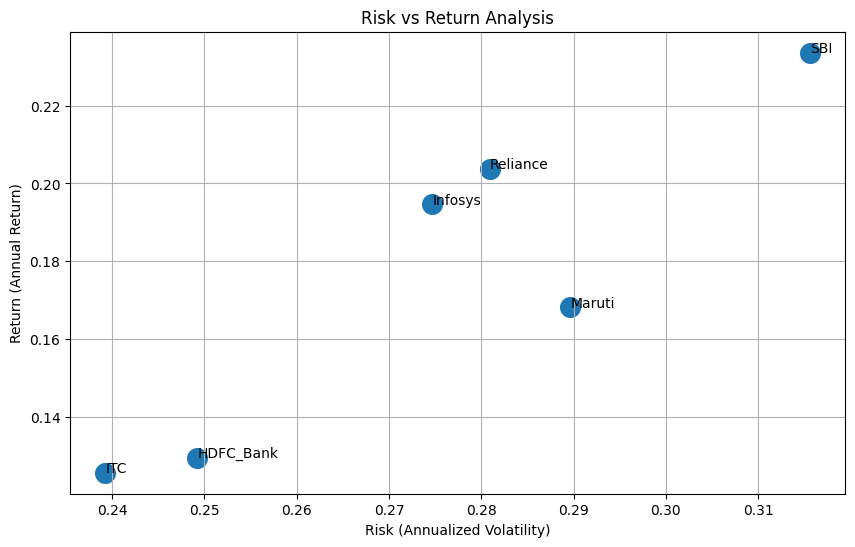

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    risk_df['Annualized_Volatility'],
    risk_df['Annual_Return'],
    s=200
)

for company in risk_df.index:
    plt.annotate(
        company,
        (
            risk_df.loc[company,'Annualized_Volatility'],
            risk_df.loc[company,'Annual_Return']
        )
    )

plt.xlabel("Risk (Annualized Volatility)")
plt.ylabel("Return (Annual Return)")
plt.title("Risk vs Return Analysis")

plt.grid(True)

plt.show()

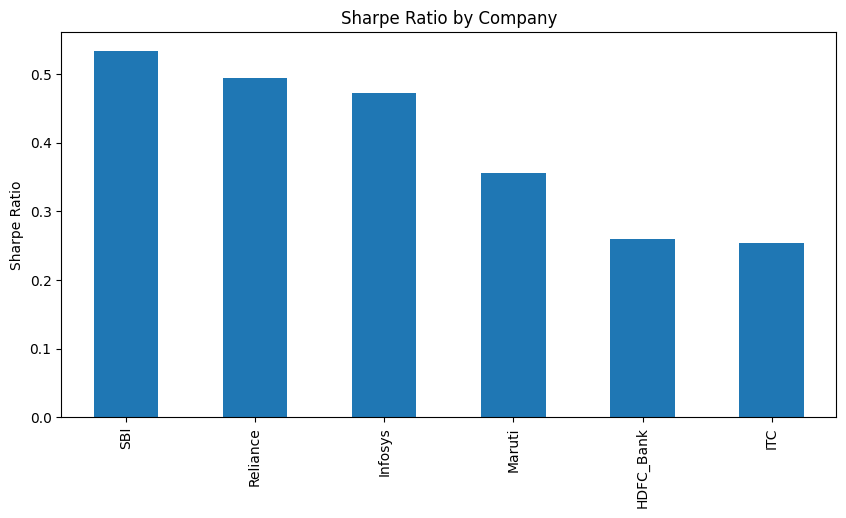

In [31]:
import matplotlib.pyplot as plt

risk_df.sort_values(
    by='Sharpe_Ratio',
    ascending=False
)['Sharpe_Ratio'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Sharpe Ratio by Company")
plt.ylabel("Sharpe Ratio")

plt.show()

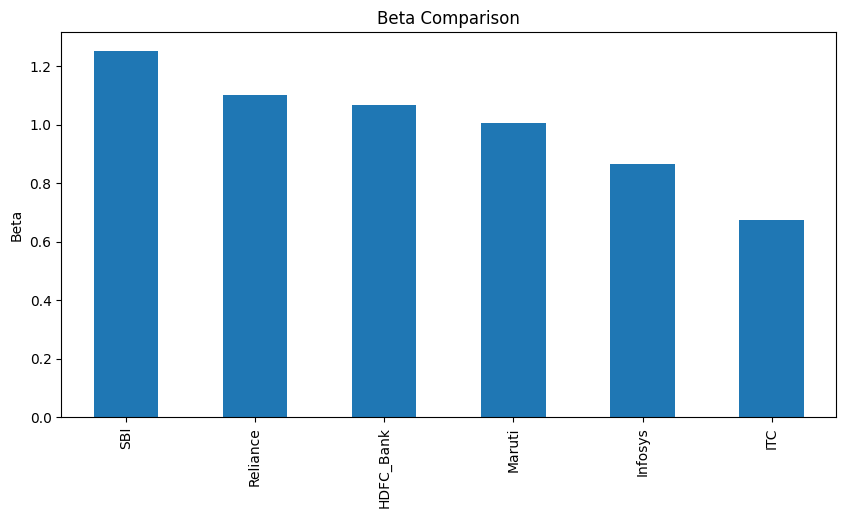

In [32]:
risk_df.sort_values(
    by='Beta',
    ascending=False
)['Beta'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Beta Comparison")
plt.ylabel("Beta")

plt.show()

In [34]:
risk_df.to_csv(
    "../data/processed/risk_summary.csv"
)